link to the dataset: https://www.kaggle.com/datasets/okeemmanuel/movie-lens-dataset?select=movies.csv

In [13]:
# ============================================================================
# CELL 1: IMPORT ALL REQUIRED LIBRARIES
# ============================================================================
# Explanation: We import all the tools we need for data processing and recommendations

import pandas as pd                    # For handling data tables
import numpy as np                     # For mathematical operations
from sklearn.feature_extraction.text import TfidfVectorizer  # For text analysis
from sklearn.neighbors import NearestNeighbors  # For finding similar items
from sklearn.metrics.pairwise import cosine_similarity  # For measuring similarity
from sklearn.preprocessing import MinMaxScaler  # For normalizing data
from scipy.sparse import csr_matrix, save_npz, load_npz  # For efficient storage
import matplotlib.pyplot as plt        # For creating graphs
import seaborn as sns                  # For better-looking graphs
import pickle                          # For saving models
import os                              # For file operations
import warnings
warnings.filterwarnings('ignore')      # Hide warning messages

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [14]:
# ============================================================================
# CELL 2: LOAD MOVIELENS DATASET FILES
# ============================================================================
# Explanation: We read the three CSV files that contain movie information

def load_data(movies_path, ratings_path, tags_path):
    """Load the three dataset files"""
    movies = pd.read_csv(movies_path)
    ratings = pd.read_csv(ratings_path)
    tags = pd.read_csv(tags_path)
    return movies, ratings, tags

# Load the files (update paths if needed)
movies, ratings, tags = load_data(
    "Dataset/movie.csv",
    "Dataset/rating.csv", 
    "Dataset/tag.csv"
)

print(f"Loaded {len(movies)} movies, {len(ratings)} ratings, {len(tags)} tags")
print("\nFirst 2 movies:")
print(movies.head(2))

Loaded 9742 movies, 100836 ratings, 3683 tags

First 2 movies:
   movieId             title                                       genres
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy
1        2    Jumanji (1995)                   Adventure|Children|Fantasy


In [15]:
# ============================================================================
# CELL 3: CLEAN AND PREPARE DATA
# ============================================================================
# Explanation: We clean the data by removing duplicates, combining tags, etc.

def clean_data(movies, ratings, tags):
    """Clean all data before using it"""
    
    # Step 1: Clean tags - remove empty ones and make lowercase
    tags = tags.dropna(subset=['tag'])
    tags['tag'] = tags['tag'].astype(str).str.lower()
    
    # Step 2: Combine multiple tags for same movie into one string
    tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
    tags_grouped.columns = ['movieId', 'tags']
    
    # Step 3: Add tags to movies dataframe
    movies = movies.merge(tags_grouped, on='movieId', how='left')
    movies['tags'] = movies['tags'].fillna('')
    
    # Step 4: Clean genres - replace | with space and make lowercase
    movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
    movies['genres'] = movies['genres'].str.lower()
    
    # Step 5: Create content feature (combine genres and tags)
    movies['content'] = movies['genres'] + ' ' + movies['tags']
    
    # Step 6: Remove duplicate movies
    movies = movies.drop_duplicates(subset=['movieId'])
    
    # Step 7: Use only 40% of ratings to save memory
    ratings = ratings.sample(frac=0.4, random_state=42)
    
    # Step 8: Combine ratings with movie info
    df = ratings.merge(movies, on='movieId')
    
    return df, movies

# Clean the data
df, movies_clean = clean_data(movies, ratings, tags)

print(f"Final dataset: {len(df)} ratings, {len(movies_clean)} movies")
print(f"Users: {df['userId'].nunique()}, Avg rating: {df['rating'].mean():.2f}")

Final dataset: 40334 ratings, 9742 movies
Users: 610, Avg rating: 3.50


In [16]:
# ============================================================================
# CELL 4: CONTENT-BASED RECOMMENDATION SYSTEM
# ============================================================================
# Explanation: This finds movies with similar genres and tags

def build_content_model(movies_df):
    """Build the content-based model using TF-IDF"""
    
    # Convert text to numbers (TF-IDF)
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = tfidf.fit_transform(movies_df['content'])
    
    # Create mapping: movie ID -> position in matrix
    movie_to_idx = {mid: i for i, mid in enumerate(movies_df['movieId'])}
    
    return tfidf, tfidf_matrix, movie_to_idx

def get_content_recs(movie_id, movies_df, tfidf_matrix, movie_to_idx, top_n=10):
    """Get similar movies using cosine similarity"""
    
    if movie_id not in movie_to_idx:
        return []
    
    # Get position of the movie
    idx = movie_to_idx[movie_id]
    
    # Calculate similarity with all movies
    similarities = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    # Get top similar movies (skip the first one which is itself)
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    
    recommendations = []
    for i in top_indices:
        if similarities[i] > 0.15:  # Only keep if similarity > 15%
            recommendations.append({
                'title': movies_df.iloc[i]['title'],
                'similarity': similarities[i],
                'genres': movies_df.iloc[i]['genres']
            })
    
    return recommendations

# Build the content model
tfidf, tfidf_matrix, movie_to_idx = build_content_model(movies_clean)
print("Content-based model ready!")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Content-based model ready!
TF-IDF matrix shape: (9742, 1677)


In [17]:
# ============================================================================
# CELL 5: COLLABORATIVE FILTERING SYSTEM
# ============================================================================
# Explanation: This finds movies that users with similar taste also liked

def build_collab_model(ratings_df, movies_df):
    """Build collaborative filtering model using KNN"""
    
    # Map movie IDs to positions
    movie_to_idx = {mid: i for i, mid in enumerate(movies_df['movieId'])}
    
    # Convert user IDs to numbers
    users = ratings_df['userId'].astype('category').cat.codes.values
    movies = ratings_df['movieId'].map(movie_to_idx).values
    ratings = ratings_df['rating'].values
    
    # Create user-item matrix (rows=users, columns=movies)
    n_users = users.max() + 1
    n_movies = len(movie_to_idx)
    user_item_matrix = csr_matrix((ratings, (users, movies)), shape=(n_users, n_movies))
    
    # Train KNN model to find similar movies
    knn = NearestNeighbors(metric='cosine', algorithm='brute')
    knn.fit(user_item_matrix.T)  # Transpose for movie-based recommendations
    
    return user_item_matrix, knn, movie_to_idx

def get_collab_recs(movie_id, movies_df, user_item_matrix, knn, movie_to_idx, top_n=10):
    """Get recommendations based on what similar users liked"""
    
    if movie_id not in movie_to_idx:
        return []
    
    # Get position of the movie
    idx = movie_to_idx[movie_id]
    
    # Find similar movies
    distances, indices = knn.kneighbors(user_item_matrix.T[idx], n_neighbors=top_n+1)
    
    recommendations = []
    for i, dist in zip(indices[0][1:], distances[0][1:]):
        similarity = 1 - dist
        if similarity > 0.15:
            recommendations.append({
                'title': movies_df.iloc[i]['title'],
                'similarity': similarity,
                'genres': movies_df.iloc[i]['genres']
            })
    
    return recommendations

# Build the collaborative model
user_item_matrix, knn, collab_movie_to_idx = build_collab_model(df, movies_clean)
print("Collaborative model ready!")
print(f"User-Item matrix shape: {user_item_matrix.shape}")

Collaborative model ready!
User-Item matrix shape: (610, 9742)


In [18]:
# ============================================================
# CELL 6: HYBRID RECOMMENDATION MERGING STRATEGY
# ============================================================
# Features Included:
#
# 1. Score Normalization
#    -> Prevents score imbalance between models
#
# 2. Adaptive Weighting
#    -> Handles cold-start and active users intelligently
#
# 3. Rank Fusion (Borda Count)
#    -> Improves robustness of recommendation ranking
#
# 4. Popularity Boost
#    -> Gives slight importance to trusted/popular movies
#
# 5. Agreement Bonus
#    -> Rewards movies recommended by BOTH systems
#
# 6. Modular & Clean Structure
#    -> Easy to maintain and explain in reports
#
# ============================================================



# ============================================================
# SCORE NORMALIZATION
# ============================================================

def normalize_scores(scores):
    """
    Normalize scores between 0 and 1
    using Min-Max normalization.
    """

    if not scores:
        return {}

    values = np.array(list(scores.values()))

    min_val = values.min()
    max_val = values.max()

    # Prevent division by zero
    if max_val - min_val < 1e-8:
        normalized = np.ones_like(values) * 0.5
    else:
        normalized = (values - min_val) / (max_val - min_val)

    return {
        item: float(score)
        for item, score in zip(scores.keys(), normalized)
    }


# ============================================================
# USER CONFIDENCE CALCULATION
# ============================================================

def get_user_confidence(user_id, ratings_df, min_ratings=5):
    """
    Calculate confidence level based on
    how many movies the user has rated.
    """

    user_ratings = ratings_df[ratings_df['userId'] == user_id]

    n_ratings = len(user_ratings)

    if n_ratings == 0:
        return 0.0

    return min(1.0, n_ratings / min_ratings)


# ============================================================
# ADAPTIVE WEIGHTING
# ============================================================

def adaptive_weights(user_confidence):
    """
    Dynamically adjust weights.

    Cold-start users:
        -> More weight to Content-Based Filtering

    Active users:
        -> More weight to Collaborative Filtering
    """

    # Cold-start user
    if user_confidence < 0.3:
        return 0.8, 0.2

    # Moderate activity
    elif user_confidence < 0.7:
        return 0.5, 0.5

    # Highly active user
    else:
        return 0.3, 0.7


# ============================================================
# RANK FUSION (BORDA COUNT METHOD)
# ============================================================

def rank_fusion(cb_scores, cf_scores, top_k=20):
    """
    Combine rankings from both models
    using Borda Count ranking strategy.
    """

    # Top recommendations from content-based filtering
    cb_top = sorted(
        cb_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    # Top recommendations from collaborative filtering
    cf_top = sorted(
        cf_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    rank_scores = {}

    # Assign rank points to content-based results
    for rank, (item, _) in enumerate(cb_top):
        rank_scores[item] = rank_scores.get(item, 0) + (top_k - rank)

    # Assign rank points to collaborative results
    for rank, (item, _) in enumerate(cf_top):
        rank_scores[item] = rank_scores.get(item, 0) + (top_k - rank)

    # Normalize final rank scores
    max_score = 2 * top_k

    return {
        item: score / max_score
        for item, score in rank_scores.items()
    }


# ============================================================
# POPULARITY BOOST
# ============================================================

def calculate_popularity_scores(ratings_df):
    """
    Calculate popularity scores based on
    number of ratings received by each movie.
    """

    popularity = ratings_df.groupby('movieId').size().to_dict()

    if not popularity:
        return {}

    scaler = MinMaxScaler()

    movie_ids = list(popularity.keys())

    counts = np.array(list(popularity.values())).reshape(-1, 1)

    normalized_counts = scaler.fit_transform(counts).flatten()

    return {
        movie: float(score)
        for movie, score in zip(movie_ids, normalized_counts)
    }


# ============================================================
# MAIN HYBRID MERGING FUNCTION
# ============================================================

def merge_recommendations(
    cb_scores,
    cf_scores,
    user_id,
    ratings_df,
    method='adaptive',
    cb_weight=0.5,
    cf_weight=0.5,
    popularity_weight=0.10,
    agreement_bonus=0.10,
    top_k_rank=20
):
    """
    Advanced Hybrid Recommendation Merging

    Parameters:
    --------------------------------------------------------
    cb_scores : dict
        Content-based recommendation scores

    cf_scores : dict
        Collaborative filtering scores

    user_id : int
        Current user ID

    ratings_df : DataFrame
        Ratings dataset

    method : str
        'adaptive', 'weighted', or 'rank'

    popularity_weight : float
        Weight for popularity boost

    agreement_bonus : float
        Extra score if both systems recommend same movie
    """

    # ========================================================
    # METHOD 1: RANK FUSION
    # ========================================================

    if method == 'rank':

        hybrid_scores = rank_fusion(
            cb_scores,
            cf_scores,
            top_k=top_k_rank
        )

    else:

        # ====================================================
        # NORMALIZE SCORES
        # ====================================================

        norm_cb = normalize_scores(cb_scores)
        norm_cf = normalize_scores(cf_scores)

        # ====================================================
        # DETERMINE WEIGHTS
        # ====================================================

        if method == 'adaptive':

            user_conf = get_user_confidence(
                user_id,
                ratings_df
            )

            cb_w, cf_w = adaptive_weights(user_conf)

        else:
            cb_w, cf_w = cb_weight, cf_weight

        # ====================================================
        # COMBINE SCORES
        # ====================================================

        hybrid_scores = {}

        all_items = set(norm_cb.keys()) | set(norm_cf.keys())

        for item in all_items:

            cb_score = norm_cb.get(item, 0.0)
            cf_score = norm_cf.get(item, 0.0)

            hybrid_score = (
                (cb_w * cb_score) +
                (cf_w * cf_score)
            )

            hybrid_scores[item] = hybrid_score

    # ========================================================
    # POPULARITY BOOST
    # ========================================================

    popularity_scores = calculate_popularity_scores(ratings_df)

    for item in hybrid_scores:

        popularity_boost = (
            popularity_weight *
            popularity_scores.get(item, 0)
        )

        hybrid_scores[item] += popularity_boost

    # ========================================================
    # AGREEMENT BONUS
    # ========================================================

    for item in hybrid_scores:

        if item in cb_scores and item in cf_scores:
            hybrid_scores[item] += agreement_bonus

    # ========================================================
    # SORT FINAL RECOMMENDATIONS
    # ========================================================

    hybrid_scores = dict(
        sorted(
            hybrid_scores.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )

    return hybrid_scores



In [19]:
# ============================================================================
# CELL 7: HYBRID RECOMMENDATION FUNCTIONS
# ============================================================================

def get_hybrid_recs(movie_id, user_id=1, top_n=5):

    print('Generating recommendations...')

    # --------------------------------------------------------
    # Content-Based Recommendations
    # --------------------------------------------------------

    content_recs = get_content_recs(
        movie_id,
        movies_clean,
        tfidf_matrix,
        movie_to_idx,
        top_n=top_n * 2
    )

    # --------------------------------------------------------
    # Collaborative Recommendations
    # --------------------------------------------------------

    collab_recs = get_collab_recs(
        movie_id,
        movies_clean,
        user_item_matrix,
        knn,
        collab_movie_to_idx,
        top_n=top_n * 2
    )

    # --------------------------------------------------------
    # Convert recommendations into dictionaries
    # --------------------------------------------------------

    content_scores = {}
    collab_scores = {}

    # Content scores
    for rec in content_recs:

        movie_match = movies_clean[
            movies_clean['title'] == rec['title']
        ]

        if not movie_match.empty:

            movie_id_found = movie_match.iloc[0]['movieId']

            content_scores[movie_id_found] = rec['similarity']

    # Collaborative scores
    for rec in collab_recs:

        movie_match = movies_clean[
            movies_clean['title'] == rec['title']
        ]

        if not movie_match.empty:

            movie_id_found = movie_match.iloc[0]['movieId']

            collab_scores[movie_id_found] = rec['similarity']

    # --------------------------------------------------------
    # Merge recommendations
    # --------------------------------------------------------

    hybrid_scores = merge_recommendations(
        cb_scores=content_scores,
        cf_scores=collab_scores,
        user_id=user_id,
        ratings_df=df,
        method='adaptive'
    )

    # --------------------------------------------------------
    # Convert results into readable format
    # --------------------------------------------------------

    recommendations = []

    for movie_id, score in list(hybrid_scores.items())[:top_n]:

        movie_data = movies_clean[
            movies_clean['movieId'] == movie_id
        ]

        if not movie_data.empty:

            recommendations.append({
                'title': movie_data.iloc[0]['title'],
                'genres': movie_data.iloc[0]['genres'],
                'score': round(score, 3)
            })

    return recommendations

In [20]:
# ============================================================================
# CELL 8: EVALUATE RECOMMENDATION QUALITY
# ============================================================================
# Explanation: We measure how good our recommendations are using Precision and Recall

def precision_at_k(recommended, relevant, k=5):
    """Precision = how many of top K recommendations were actually relevant"""
    if len(recommended) == 0:
        return 0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k=5):
    """Recall = how many relevant items we found in top K"""
    if len(relevant) == 0:
        return 0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant)

def evaluate_system(num_users=20, k=5):
    """Test on random users to get average precision and recall"""
    
    # Get users with at least 10 ratings
    user_counts = df.groupby('userId').size()
    active_users = user_counts[user_counts >= 10].index.tolist()
    test_users = np.random.choice(active_users, min(num_users, len(active_users)), replace=False)
    
    precisions = []
    recalls = []
    
    for user_id in test_users:
        # Get user's liked movies (rating >= 4)
        user_ratings = df[df['userId'] == user_id]
        liked = user_ratings[user_ratings['rating'] >= 4]['movieId'].values
        
        if len(liked) < 2:
            continue
        
        # Use first liked movie as seed
        seed = liked[0]
        recs = get_hybrid_recs(seed, user_id=user_id, top_n=k)
        
        rec_titles = [r['title'] for r in recs]
        relevant_titles = set(movies_clean[movies_clean['movieId'].isin(liked[1:])]['title'].values)
        
        if relevant_titles:
            precisions.append(precision_at_k(rec_titles, relevant_titles, k))
            recalls.append(recall_at_k(rec_titles, relevant_titles, k))
    
    if precisions:
        print(f"\nEvaluation Results (tested on {len(precisions)} users):")
        print(f"Precision@{k}: {np.mean(precisions):.3f}")
        print(f"Recall@{k}: {np.mean(recalls):.3f}")
        print(f"F1-Score: {2 * np.mean(precisions) * np.mean(recalls) / (np.mean(precisions) + np.mean(recalls) + 1e-8):.3f}")

# Run evaluation
print("Evaluating system...")
evaluate_system(num_users=30, k=5)

Evaluating system...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...
Generating recommendations...

Evaluation Results (tested on 29 users):
Precision@5: 0.152
Recall@5: 0.023
F1-Score: 0.039


In [21]:
# ============================================================================
# CELL 9: COMPARE OLD VS NEW MERGING STRATEGY
# ============================================================================

def compare_old_vs_new(num_users=30, k=5):
    """Compare old merging (weighted) vs new merging (adaptive)"""
    
    user_counts = df.groupby('userId').size()
    test_users = user_counts[user_counts >= 10].sample(min(num_users, len(user_counts))).index
    
    old_scores = []  # Simple weighted average
    new_scores = []  # Adaptive strategy
    
    for user_id in test_users:
        liked = df[(df['userId'] == user_id) & (df['rating'] >= 4)]['movieId'].values
        
        if len(liked) < 2:
            continue
        
        seed = liked[0]
        relevant_ids = set(liked[1:])
        
        # Get scores
        content_scores = {}
        for rec in get_content_recs(seed, movies_clean, tfidf_matrix, movie_to_idx, top_n=20):
            mid = movies_clean[movies_clean['title'] == rec['title']]['movieId'].values
            if len(mid) > 0:
                content_scores[mid[0]] = rec['similarity']
        
        collab_scores = {}
        for rec in get_collab_recs(seed, movies_clean, user_item_matrix, knn, collab_movie_to_idx, top_n=20):
            mid = movies_clean[movies_clean['title'] == rec['title']]['movieId'].values
            if len(mid) > 0:
                collab_scores[mid[0]] = rec['similarity']
        
        # OLD strategy (simple weighted)
        old_merged = merge_recommendations(content_scores, collab_scores, user_id, df, method='weighted')
        old_ids = list(old_merged.keys())[:k]
        
        # NEW strategy (adaptive)
        new_merged = merge_recommendations(content_scores, collab_scores, user_id, df, method='adaptive')
        new_ids = list(new_merged.keys())[:k]
        
        # Calculate precision
        old_hits = len(set(old_ids) & relevant_ids)
        new_hits = len(set(new_ids) & relevant_ids)
        
        old_scores.append(old_hits / k)
        new_scores.append(new_hits / k)
    
    # Print results
    print("\n" + "="*50)
    print("OLD vs NEW MERGING STRATEGY")
    print("="*50)
    print(f"Old Strategy (Weighted): {np.mean(old_scores):.3f}")
    print(f"New Strategy (Adaptive): {np.mean(new_scores):.3f}")
    print(f"\n✅ Improvement: {(np.mean(new_scores) - np.mean(old_scores)) * 100:.1f}% better")
    print("="*50)

compare_old_vs_new()


OLD vs NEW MERGING STRATEGY
Old Strategy (Weighted): 0.107
New Strategy (Adaptive): 0.167

✅ Improvement: 6.0% better


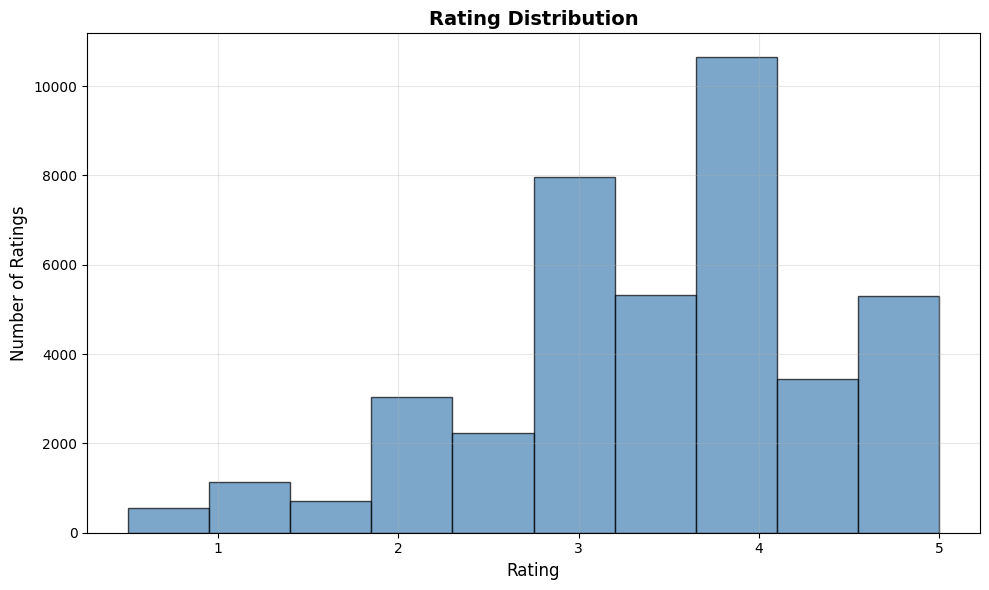

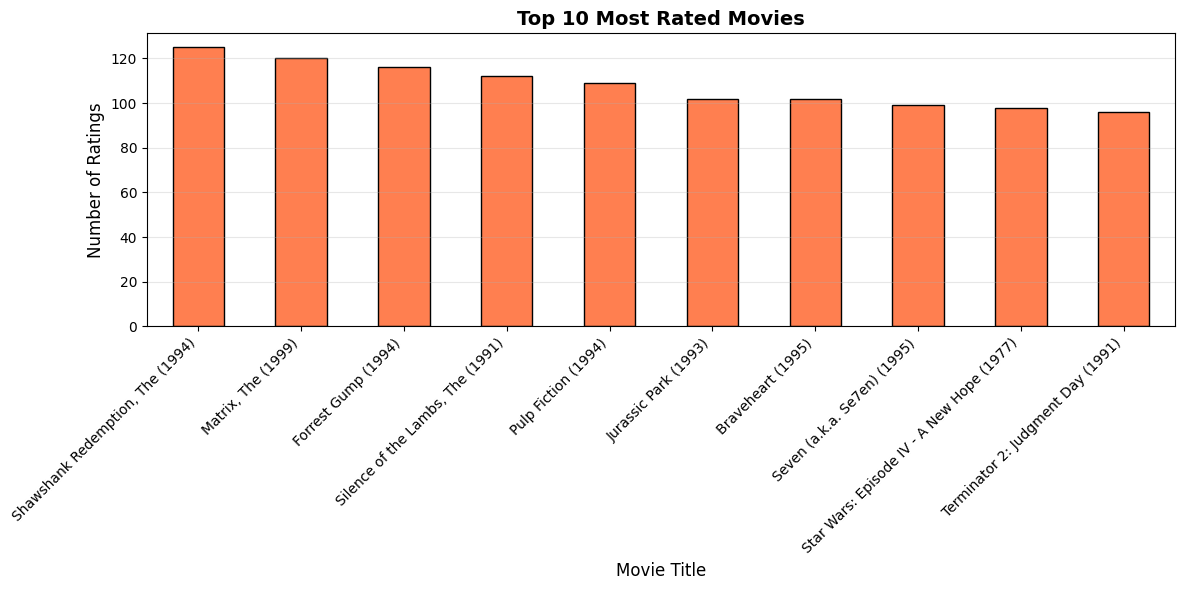

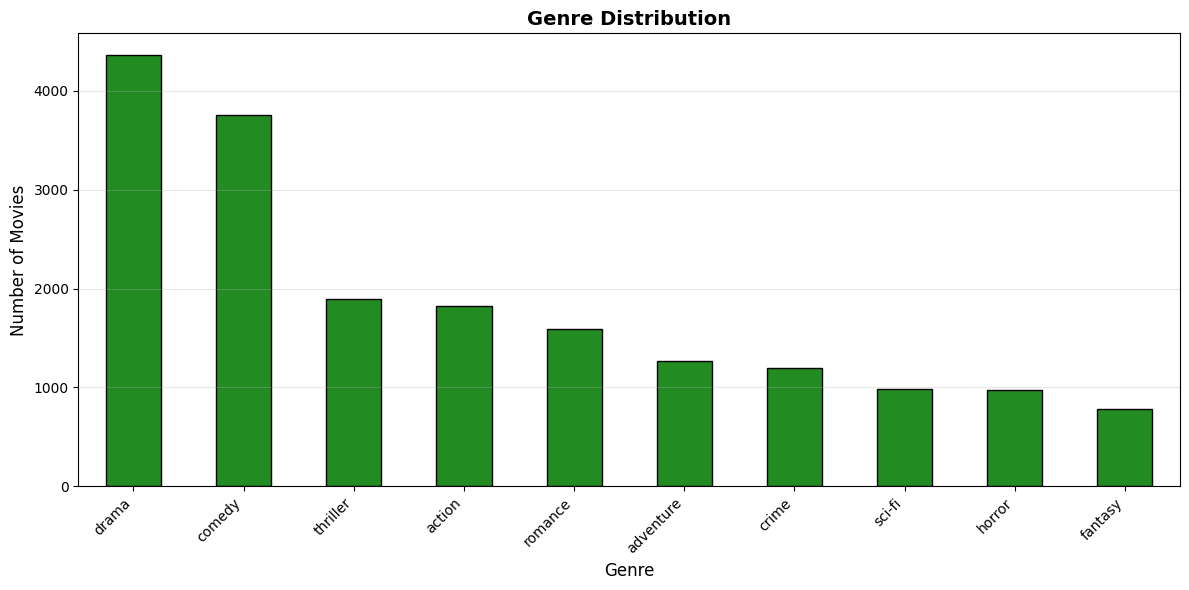


Visualizations complete!


In [22]:
# ============================================================================
# STEP 10: CREATE VISUALIZATIONS
# ============================================================================
# Explanation: We create 3 graphs as required by the client


# Graph 1: Rating Distribution
# ============================================================================
plt.figure(figsize=(10, 6))
plt.hist(df['rating'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/rating_distribution.png')  # Save the figure as an image file
plt.show()

# Graph 2: Top 10 Most Rated Movies
# ============================================================================
plt.figure(figsize=(12, 6))
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
top_movies.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Most Rated Movies', fontsize=14, fontweight='bold')
plt.xlabel('Movie Title', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./figures/top_rated_movies.png')  # Save the figure as an image file
plt.show()

# Graph 3: Genre Distribution
# ============================================================================
all_genres = []
for genres in movies_clean['genres'].str.split():
    if genres:
        all_genres.extend(genres)

genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Genre Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./figures/genre_distribution.png')  # Save the figure as an image file
plt.show()

print("\nVisualizations complete!")

In [23]:
# ============================================================================
# CELL 11: SAVE MODELS FOR LATER USE
# ============================================================================
# Explanation: We save all trained models so we can use them without retraining

def save_models():
    """Save all models to disk"""
    
    os.makedirs('models', exist_ok=True)
    
    # Save each component
    with open('models/tfidf.pkl', 'wb') as f:
        pickle.dump(tfidf, f)
    
    with open('models/movie_to_idx.pkl', 'wb') as f:
        pickle.dump(movie_to_idx, f)
    
    with open('models/knn.pkl', 'wb') as f:
        pickle.dump(knn, f)
    
    with open('models/movies.pkl', 'wb') as f:
        pickle.dump(movies_clean, f)
    
    # Save matrices (sparse format for efficiency)
    save_npz('models/tfidf_matrix.npz', tfidf_matrix)
    save_npz('models/user_item_matrix.npz', user_item_matrix)
    
    print("All models saved to 'models/' folder!")

# Save everything
print("Saving models...")
save_models()

Saving models...
All models saved to 'models/' folder!


In [24]:
# ============================================================================
# CELL 12: UTILITY FUNCTIONS (Search, Popular, etc.)
# ============================================================================
# Explanation: Helper functions for searching and finding popular movies

def search_movies(query, limit=10):
    """Search for movies by name"""
    query = query.lower()
    results = movies_clean[movies_clean['title'].str.lower().str.contains(query)]
    return results['title'].head(limit).tolist()

def get_popular_movies(min_ratings=5, top_n=10):
    """Get most popular movies (for new users)"""
    stats = df.groupby('movieId').agg({'rating': ['mean', 'count']}).reset_index()
    stats.columns = ['movieId', 'avg_rating', 'count']
    popular = stats[stats['count'] >= min_ratings].sort_values('avg_rating', ascending=False)
    
    results = []
    for _, row in popular.head(top_n).iterrows():
        title = movies_clean[movies_clean['movieId'] == row['movieId']]['title'].values[0]
        results.append((title, row['avg_rating'], row['count']))
    
    return results

def get_movies_by_genre(genre, top_n=10):
    """Get movies from a specific genre"""
    genre = genre.lower()
    matches = movies_clean[movies_clean['genres'].str.contains(genre)]
    return matches['title'].head(top_n).tolist()

# Test the utilities
print("Testing search: 'matrix'")
print(search_movies("matrix", limit=3))

print("\nPopular movies:")
popular = get_popular_movies(min_ratings=10, top_n=5)
for i, (title, rating, count) in enumerate(popular, 1):
    print(f"{i}. {title} (Rating: {rating:.2f}, {count} ratings)")

Testing search: 'matrix'
['Matrix, The (1999)', 'Matrix Reloaded, The (2003)', 'Matrix Revolutions, The (2003)']

Popular movies:
1. Cinema Paradiso (Nuovo cinema Paradiso) (1989) (Rating: 4.88, 12.0 ratings)
2. Dancer in the Dark (2000) (Rating: 4.55, 10.0 ratings)
3. Once Upon a Time in the West (C'era una volta il West) (1968) (Rating: 4.50, 12.0 ratings)
4. On the Waterfront (1954) (Rating: 4.45, 11.0 ratings)
5. Little Big Man (1970) (Rating: 4.45, 11.0 ratings)


In [25]:
# ============================================================
# CELL 13: FINAL RECOMMENDATION FUNCTION
# ============================================================

def recommend_movie(movie_name, top_n=5):
    """Get recommendations for a movie"""
    # Find movie ID
    movie_match = movies_clean[movies_clean['title'].str.lower().str.contains(movie_name.lower())]
    
    if movie_match.empty:
        print(f"Movie '{movie_name}' not found!")
        return
    
    movie_id = movie_match.iloc[0]['movieId']
    movie_title = movie_match.iloc[0]['title']
    
    print(f"\nRecommendations based on '{movie_title}':")
    print("-" * 40)
    
    recs = get_hybrid_recs(movie_id, top_n=top_n)
    
    for i, rec in enumerate(recs, 1):
        print(f"{i}. {rec['title']}")
        print(f"   Genre: {rec['genres']}")
        print(f"   Score: {rec['score']}")
        print()

In [26]:
# ============================================================================
# CELL 14: COMMAND LINE INTERFACE
# ============================================================================
# Explanation: Interactive menu for users to get recommendations

def main_menu():
    """Interactive command line menu"""
    
    print("\n" + "="*60)
    print("MOVIE RECOMMENDATION SYSTEM")
    print("Content-Based + Collaborative Filtering")
    print("="*60)
    
    while True:
        print("\n" + "-"*40)
        print("MAIN MENU")
        print("-"*40)
        print("1. Get movie recommendations")
        print("2. Search for a movie")
        print("3. Browse by genre")
        print("4. View popular movies")
        print("5. Exit")
        
        choice = input("\nEnter your choice (1-5): ")
        
        if choice == '1':
            movie = input("Enter movie name: ").strip()
            if movie:
                recommend_movie(movie, top_n=5)
        
        elif choice == '2':
            query = input("Search for movie: ").strip()
            if query:
                results = search_movies(query, limit=10)
                if results:
                    print(f"\nFound {len(results)} movies:")
                    for i, title in enumerate(results, 1):
                        print(f"  {i}. {title}")
                    
                    pick = input("\nGet recommendations? (enter number or 'no'): ")
                    if pick.isdigit() and 1 <= int(pick) <= len(results):
                        recommend_movie(results[int(pick)-1])
                else:
                    print(f"No movies found for '{query}'")
        
        elif choice == '3':
            print("\nPopular genres: action, comedy, drama, romance, thriller, sci-fi")
            genre = input("Enter genre: ").strip().lower()
            if genre:
                movies = get_movies_by_genre(genre, top_n=10)
                if movies:
                    print(f"\nTop {genre.upper()} movies:")
                    for i, title in enumerate(movies, 1):
                        print(f"  {i}. {title}")
                    
                    pick = input("\nGet recommendations? (enter number or 'no'): ")
                    if pick.isdigit() and 1 <= int(pick) <= len(movies):
                        recommend_movie(movies[int(pick)-1])
                else:
                    print(f"No movies found in '{genre}' genre")
        
        elif choice == '4':
            print("\nMost Popular Movies:")
            popular = get_popular_movies(min_ratings=10, top_n=10)
            for i, (title, rating, count) in enumerate(popular, 1):
                print(f"{i}. {title} (Rating: {rating:.2f}, {count} ratings)")
        
        elif choice == '5':
            print("\nThank you for using the system! Goodbye!")
            break
        
        else:
            print("Invalid choice. Please enter 1-5.")

# Run the interface and handle graceful exit
if __name__ == "__main__":
    try:
        main_menu()
    except KeyboardInterrupt:
        print("\n\nGoodbye! 👋")


MOVIE RECOMMENDATION SYSTEM
Content-Based + Collaborative Filtering

----------------------------------------
MAIN MENU
----------------------------------------
1. Get movie recommendations
2. Search for a movie
3. Browse by genre
4. View popular movies
5. Exit

Thank you for using the system! Goodbye!
